In [8]:
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import polars as pl
import scienceplots
import seaborn as sns

from qr.utils import *

sns.set_style("whitegrid")
plt.style.use(["science", "grid", "no-latex"])

In [2]:
ticker = "PFE"
df, df_emp = load_data(ticker)

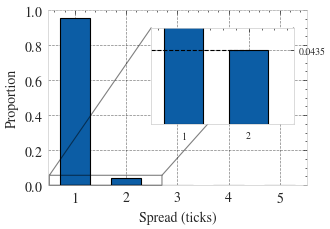

In [3]:
with transparent():
    spread_dist = (
        df_emp.filter(pl.col("event").eq("Trade"))
        .select(pl.col("spread").value_counts(normalize=True))
        .unnest("spread")
        .sort("spread")
        .filter(pl.col("spread") <= 5)
    )
    spreads = spread_dist["spread"].to_numpy()
    props = spread_dist["proportion"].to_numpy()
    val_2 = props[spreads == 2][0]

    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    ax.bar(spreads, props, width=0.6, edgecolor="k", linewidth=0.8)
    ax.set_xticks(spreads)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Spread (ticks)")
    ax.set_ylabel("Proportion")

    # Inset zoom
    axins = ax.inset_axes([0.4, 0.35, 0.55, 0.55])
    axins.bar(spreads, props, width=0.6, edgecolor="k", linewidth=0.8)
    axins.set_xlim(0.5, 2.7)
    axins.set_ylim(0, val_2 * 1.3)
    axins.set_xticks([1, 2])
    axins.hlines(
        val_2, axins.get_xlim()[0], 2, linestyles="--", colors="k", linewidth=0.8
    )
    axins.set_yticks([val_2])
    axins.yaxis.tick_right()
    axins.set_yticklabels([f"{val_2:.4f}"], fontsize=16)
    axins.tick_params(labelsize=7)

    # Connect zoom region to inset
    ax.indicate_inset_zoom(axins, edgecolor="k", linewidth=0.8)
    fig.patch.set_alpha(0)
    ax.set_facecolor("white")
    fig.tight_layout()
    plt.show()
    # fig.savefig(
    #     "../../paper/spread_before_trades_pfe.pdf", bbox_inches="tight", transparent=True
    # )

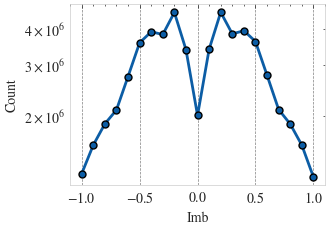

In [4]:
with transparent():
    count = df.group_by("imbalance").agg(pl.col("len").sum()).sort("imbalance")
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    ax.plot(
        count["imbalance"],
        count["len"],
        marker="o",
        mec="k",
        ms=5,
        lw=2,
    )
    ax.set_xlabel("Imb")
    ax.set_ylabel("Count")
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
    ax.set_yscale("log")
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    fig.patch.set_alpha(0)
    ax.set_facecolor("white")
    fig.tight_layout()
    plt.show()
    # fig.savefig("../../paper/imb_count_PFE.pdf", bbox_inches="tight")

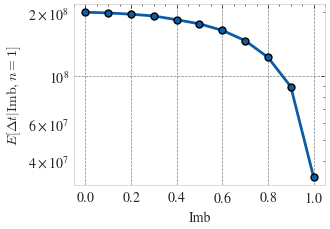

In [5]:
with transparent():
    delta_t = est.exp_delta_t(df.lazy())
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    ax.plot(
        delta_t.filter(pl.col("spread").eq(1))["imbalance"],
        delta_t.filter(pl.col("spread").eq(1))["average_dt"],
        marker="o",
        mec="k",
        ms=5,
        lw=2,
    )
    ax.set_xlabel("Imb")
    ax.set_ylabel(r"$E[\Delta t | \text{Imb}, n=1]$")
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
    ax.set_yscale("log")
    fig.patch.set_alpha(0)
    ax.set_facecolor("white")
    fig.tight_layout()
    plt.show()
    # fig.savefig("../../paper/avg_delta_t_PFE.pdf", bbox_inches="tight")

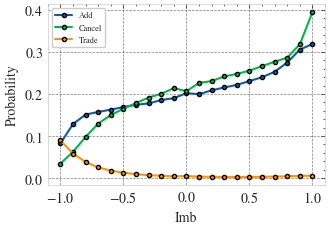

In [6]:
probabilities = pl.read_csv(f"../../data/{ticker}/qr_params/event_probabilities.csv")
probs = pl.concat(
    [
        probabilities.filter(pl.col("imbalance").ne(0)).with_columns(
            imbalance=-pl.col("imbalance"),
            side=-pl.col("side"),
            queue=-pl.col("queue"),
            event=pl.col("event").replace(
                {"Create_Ask": "Create_Bid", "Create_Bid": "Create_Ask"}
            ),
        ),
        probabilities,
    ]
).sort("imbalance", "spread", "event", "queue")
with transparent():
    fig, ax = plt.subplots(figsize=(3.5, 2.5))

    sub = probs.filter(pl.col("spread").eq(1) & pl.col("queue").eq(-1))
    for event in ["Add", "Cancel", "Trade"]:
        data = sub.filter(pl.col("event").eq(event)).sort("imbalance")
        ax.plot(
            data["imbalance"],
            data["probability"],
            marker="o",
            ms=3,
            lw=1.5,
            label=event,
            mec="k",
        )

    ax.set_xlabel("Imb")
    ax.set_ylabel("Probability")
    ax.legend(fontsize=6)
    fig.patch.set_alpha(0)
    ax.set_facecolor("white")
    fig.tight_layout()
    plt.show()
    # fig.savefig(
    #     "../../paper/event_probabilities_spread_1_bid_PFE.pdf",
    #     bbox_inches="tight",
    # )
    plt.show()

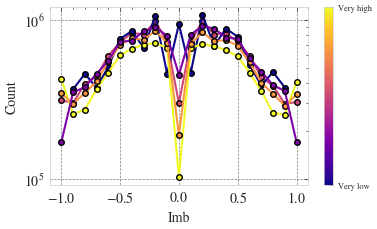

In [11]:
norm = mcolors.Normalize(vmin=0, vmax=4)
cmap = cm.plasma

stats = (
    df.group_by("imbalance", "spread", "total_best")
    .agg(pl.col("delta_t_sum").sum() / pl.col("len").sum(), pl.col("len").sum())
    .sort("imbalance")
)

with transparent():
    fig, ax = plt.subplots(figsize=(4, 2.5))
    for (total_best,), data in stats.filter(pl.col("spread").eq(1)).group_by("total_best"):
        ax.plot(
            data["imbalance"],
            data["len"],
            marker="o",
            ms=4,
            lw=1.5,
            mec="k",
            color=cmap(norm(total_best)),
        )
    ax.set_xlabel("Imb")
    ax.set_ylabel("Count")
    ax.set_yscale("log")
    
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, ticks=[0, 4])
    cbar.ax.set_yticklabels(["Very low", "Very high"], fontsize=6)
    fig.patch.set_alpha(0)
    ax.set_facecolor("white")
    fig.tight_layout()
    plt.show()
    # fig.savefig(
    #     "../../paper/count_imb_total_best_PFE.pdf", bbox_inches="tight", transparent=True
    # )

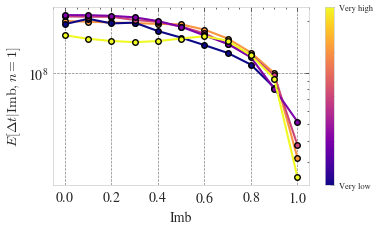

In [12]:
stats = (
    df.group_by(pl.col("imbalance").abs(), "spread", "total_best")
    .agg(pl.col("delta_t_sum").sum() / pl.col("len").sum(), pl.col("len").sum())
    .sort("imbalance")
)

with transparent():
    fig, ax = plt.subplots(figsize=(4, 2.5))
    for (total_best,), data in stats.filter(pl.col("spread").eq(1)).group_by("total_best"):
        ax.plot(
            data["imbalance"],
            data["delta_t_sum"],
            marker="o",
            ms=4,
            lw=1.5,
            mec="k",
            color=cmap(norm(total_best)),
        )
    ax.set_xlabel("Imb")
    ax.set_ylabel(r"$E[\Delta t | \text{Imb}, n=1]$")
    ax.set_yscale("log")
    
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, ticks=[0, 4])
    cbar.ax.set_yticklabels(["Very low", "Very high"], fontsize=6)
    fig.patch.set_alpha(0)
    ax.set_facecolor("white")
    
    fig.tight_layout()
    plt.show()
    # fig.savefig(
    #     "../../paper/avg_delta_t_total_best_PFE.pdf", bbox_inches="tight", transparent=True
    # )

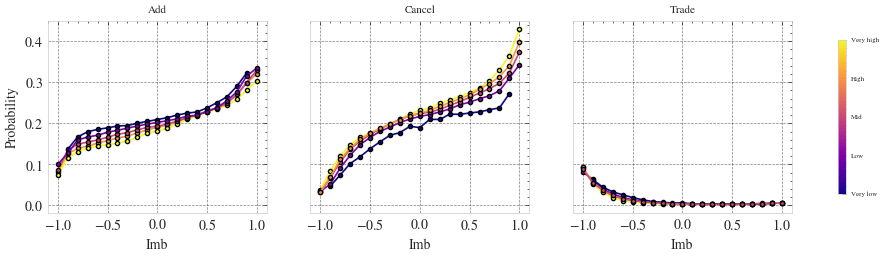

In [13]:
stats = (
    df.group_by("imbalance", "spread", "total_best", "queue", "side", "event")
    .agg(pl.col("len").sum(), pl.col("delta_t_sum").sum())
    .with_columns(
        total_len_cat=pl.col("len").sum().over("imbalance", "spread", "total_best")
    )
)

probabilities_3d = stats.select(
    "imbalance",
    "spread",
    "total_best",
    "queue",
    "side",
    "event",
    probability=pl.col("len").truediv(pl.col("total_len_cat")),
).sort("imbalance", "spread", "total_best", "queue", "side", "event")

pos = probabilities_3d.filter(pl.col("imbalance") >= 0)
neg = probabilities_3d.filter(pl.col("imbalance") <= 0).with_columns(
    imbalance=-pl.col("imbalance"),
    side=-pl.col("side"),
    queue=-pl.col("queue"),
    event=pl.col("event").replace(
        {"Create_Ask": "Create_Bid", "Create_Bid": "Create_Ask"}
    ),
)

probabilities_3d = (
    pl.concat([pos, neg])
    .group_by("imbalance", "spread", "total_best", "event", "queue", "side")
    .agg(
        probability=pl.col("probability").mean(),
    )
)

probabilities_3d = probabilities_3d.sort(
    "imbalance", "spread", "total_best", "event", "queue"
)

probs = pl.concat(
    [
        probabilities_3d.filter(pl.col("imbalance").ne(0)).with_columns(
            imbalance=-pl.col("imbalance"),
            side=-pl.col("side"),
            queue=-pl.col("queue"),
            event=pl.col("event").replace(
                {"Create_Ask": "Create_Bid", "Create_Bid": "Create_Ask"}
            ),
        ),
        probabilities_3d,
    ]
).sort("imbalance", "spread", "event", "queue")
probs = probs.filter(pl.col("spread").eq(1) & pl.col("queue").eq(-1))

probs_bid = probs.filter(pl.col("spread").eq(1) & pl.col("queue").eq(-1))


with transparent():
    fig, axes = plt.subplots(1, 3, figsize=(12, 2.5), sharey=True)
    
    for ax, event in zip(axes, ["Add", "Cancel", "Trade"]):
        data = probs_bid.filter(pl.col("event").eq(event))
        for (tb,), group in data.group_by("total_best"):
            group = group.sort("imbalance")
            ax.plot(
                group["imbalance"],
                group["probability"],
                marker="o",
                ms=3,
                lw=1.2,
                mec="k",
                color=cmap(norm(tb)),
            )
        ax.set_xlabel("Imb")
        ax.set_title(event, fontsize=8)
    
    axes[0].set_ylabel("Probability")
    
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=axes, ticks=[0, 1, 2, 3, 4], shrink=0.8)
    cbar.ax.set_yticklabels(["Very low", "Low", "Mid", "High", "Very high"], fontsize=5)
    fig.patch.set_alpha(0)
    ax.set_facecolor("white")
    # fig.tight_layout()
    plt.show()
    # fig.savefig(
    #     "../../paper/probabilities_total_best_PFE.pdf", bbox_inches="tight", transparent=True
    # )

In [14]:
df = df.with_columns(pl.col("date").cast(pl.Date))

# Create a period label based on 6-month intervals
df = df.with_columns(
    (
        pl.col("date").dt.year().cast(pl.Utf8)
        + "_H"
        + ((pl.col("date").dt.month() - 1) // 6 + 1).cast(pl.Utf8)
    ).alias("period")
)

# Split into a dict of DataFrames keyed by period
periods = dict(
    sorted(
        ((name[0], group) for name, group in df.group_by("period")), key=lambda x: x[0]
    )
)

In [15]:
probabilities = {
    name: est.event_probabilities(period.lazy())
    for name, period in periods.items()
    if name != "2023_H2"
}
delta_t = {
    name: est.exp_delta_t(period.lazy())
    for name, period in periods.items()
    if name != "2023_H2"
}

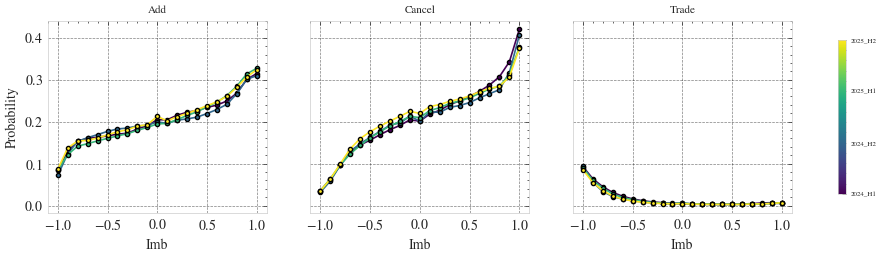

In [16]:
# Combine all periods into one DataFrame with a "period" column
probs_all = pl.concat(
    [p.with_columns(pl.lit(name).alias("period")) for name, p in probabilities.items()]
)

# Symmetrize (same logic, just without total_best)
pos = probs_all.filter(pl.col("imbalance") >= 0)
neg = probs_all.filter(pl.col("imbalance") <= 0).with_columns(
    imbalance=-pl.col("imbalance"),
    side=-pl.col("side"),
    queue=-pl.col("queue"),
    event=pl.col("event").replace(
        {"Create_Ask": "Create_Bid", "Create_Bid": "Create_Ask"}
    ),
)

probs_sym = (
    pl.concat([pos, neg])
    .group_by("imbalance", "spread", "event", "queue", "side", "period")
    .agg(probability=pl.col("probability").mean())
)

# Mirror to negative imbalances
probs_full = pl.concat(
    [
        probs_sym.filter(pl.col("imbalance").ne(0)).with_columns(
            imbalance=-pl.col("imbalance"),
            side=-pl.col("side"),
            queue=-pl.col("queue"),
            event=pl.col("event").replace(
                {"Create_Ask": "Create_Bid", "Create_Bid": "Create_Ask"}
            ),
        ),
        probs_sym,
    ]
).sort("imbalance", "spread", "event", "queue", "period")

probs_bid = probs_full.filter(pl.col("spread").eq(1) & pl.col("queue").eq(-1))

# Plot
sorted_periods = sorted(probs_bid["period"].unique().to_list())
norm = mcolors.Normalize(vmin=0, vmax=len(sorted_periods) - 1)
cmap = cm.viridis  # or your preferred colormap

with transparent():
    fig, axes = plt.subplots(1, 3, figsize=(12, 2.5), sharey=True)
    
    for ax, event in zip(axes, ["Add", "Cancel", "Trade"]):
        data = probs_bid.filter(pl.col("event").eq(event))
        for i, period in enumerate(sorted_periods):
            group = data.filter(pl.col("period").eq(period)).sort("imbalance")
            ax.plot(
                group["imbalance"],
                group["probability"],
                marker="o",
                ms=3,
                lw=1.2,
                mec="k",
                color=cmap(norm(i)),
                label=period,
            )
        ax.set_xlabel("Imb")
        ax.set_title(event, fontsize=8)
    
    axes[0].set_ylabel("Probability")
    
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=axes, ticks=range(len(sorted_periods)), shrink=0.8)
    cbar.ax.set_yticklabels(sorted_periods, fontsize=5)
    ax.patch.set_facecolor("white")
    # fig.savefig(
    #     "../../paper/probabilities_over_time_PFE.pdf", bbox_inches="tight", transparent=True
    # )
    plt.show()

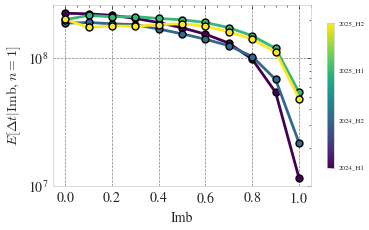

In [17]:
sorted_periods = sorted(delta_t.keys())
norm = mcolors.Normalize(vmin=0, vmax=len(sorted_periods) - 1)
cmap = cm.viridis

with transparent():
    fig, ax = plt.subplots(figsize=(4, 2.5))
    for i, period in enumerate(sorted_periods):
        data = delta_t[period].filter(pl.col("spread").eq(1)).sort("imbalance")
        ax.plot(
            data["imbalance"],
            data["average_dt"],
            marker="o",
            ms=5,
            lw=2,
            mec="k",
            color=cmap(norm(i)),
        )
    ax.set_xlabel("Imb")
    ax.set_ylabel(r"$E[\Delta t | \text{Imb}, n=1]$")
    ax.set_yscale("log")
    
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, ticks=range(len(sorted_periods)), shrink=0.8)
    cbar.ax.set_yticklabels(sorted_periods, fontsize=5)
    ax.patch.set_facecolor("white")
    # fig.savefig("../../paper/delta_t_over_time_PFE.pdf", bbox_inches="tight", transparent=True)
    fig.tight_layout()
    plt.show()